In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
pallete = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}

In [2]:
def frac_bin(df):
    total_sistemas = len(df)
    # Número de sistemas binários (comp_mass > 0)
    num_binarias = (df['comp_mass'] > 0).sum()
    return num_binarias/total_sistemas

In [3]:
# Leitura dos dados
data = pd.read_csv('data.csv', index_col='Cluster')
data = data[data['Pmemb']>.6]
df = pd.read_csv('log-results-eDR3-MF_integrada.csv', index_col='Cluster')
for aglomerado in df.index:
    df.bin_frac.loc[aglomerado] = frac_bin(data.loc[aglomerado])



df2 = df[df.Av<1.5]
df3 = df[df.Av>1.5]

parametros = ['dist', 'age', 'FeH', 'bin_frac']

# Distribuição dos dados

In [4]:
print('                        Dados de toda amostra\n')
print(df[parametros].describe(percentiles = [.5]))
print('______________________________________________________________________\n')
print('                        Dados Aglomerados Baixo Av\n')
print(df2[parametros].describe(percentiles = [.5]))
print('______________________________________________________________________\n')
print('                        Dados Aglomerados Alto Av\n')
print(df3[parametros].describe(percentiles = [.5]))

                        Dados de toda amostra

             dist         age         FeH    bin_frac
count  771.000000  771.000000  771.000000  771.000000
mean     1.749992    8.184106   -0.035634    0.583974
std      0.996614    0.635382    0.107249    0.114286
min      0.135000    6.673000   -0.373000    0.227915
50%      1.636000    8.249000   -0.036000    0.583333
max      6.866000    9.590000    0.426000    0.900929
______________________________________________________________________

                        Dados Aglomerados Baixo Av

             dist         age         FeH    bin_frac
count  429.000000  429.000000  429.000000  429.000000
mean     1.428051    8.303228   -0.034760    0.546697
std      0.910020    0.584789    0.096576    0.119726
min      0.135000    6.685000   -0.373000    0.227915
50%      1.210000    8.317000   -0.033000    0.536585
max      4.777000    9.590000    0.426000    0.900929
______________________________________________________________________

 

A descrição dos dados indica que como esperado os aglomerados com alto Av, em geral estão mais distantes e possuem uma fração de binárias maior comparados com os aglomerados de baixo avermelhamento.
Em relação a idade e a metalicidade não há muita diferença na descrição dos dados

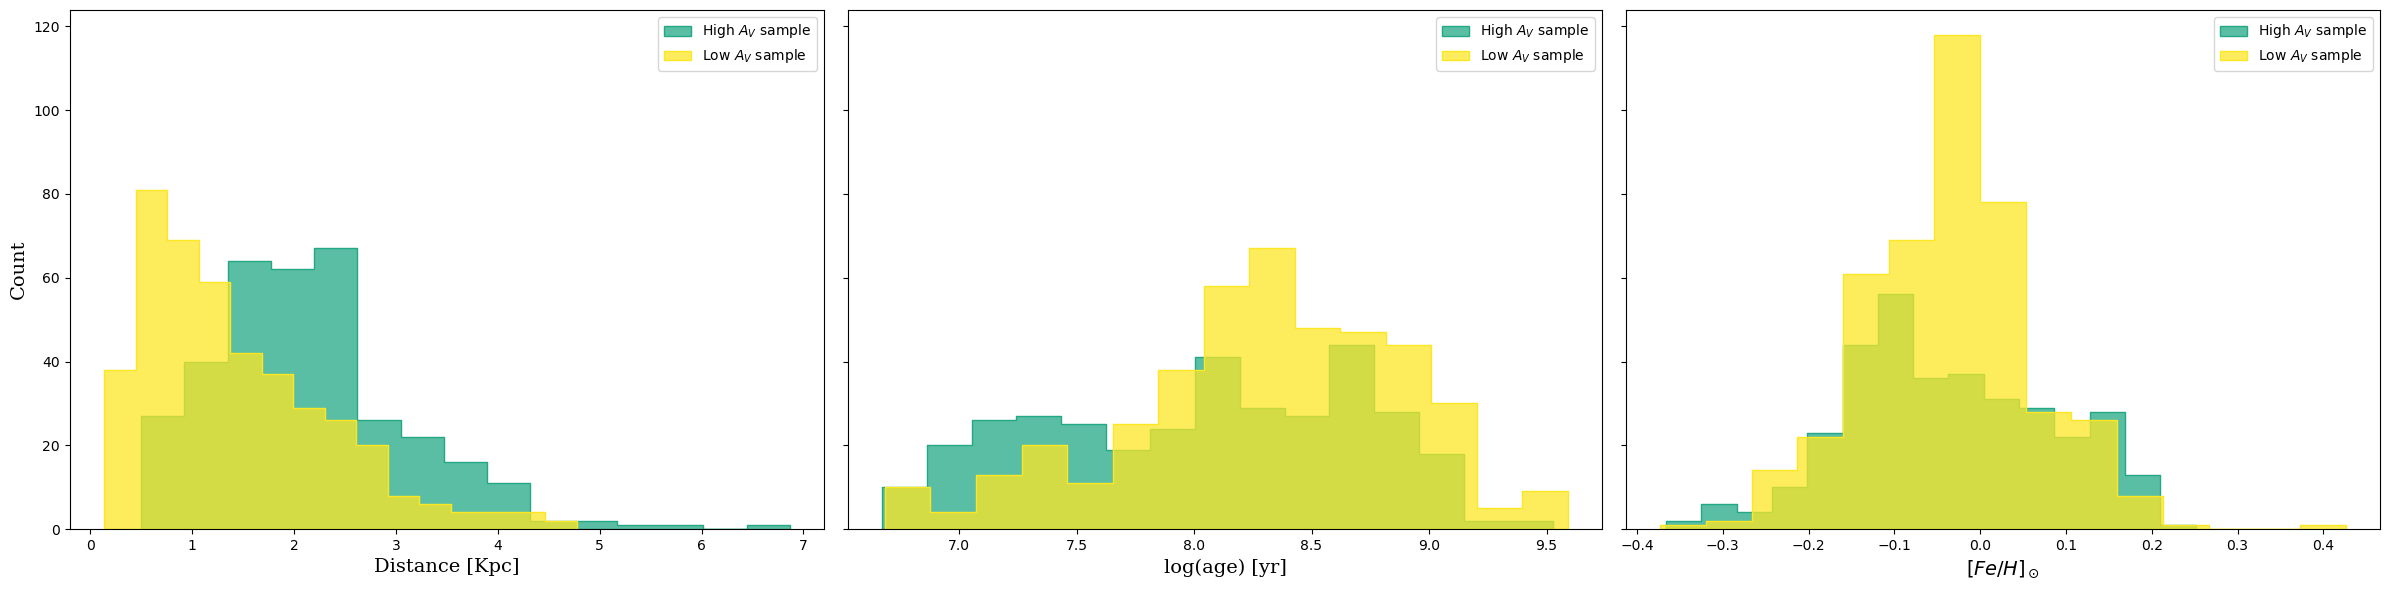

In [198]:
n_rows = 1
n_cols = 3
parametros = ['dist', 'age', 'FeH',]
label = ['Distance [Kpc]', 'log(age) [yr]', r'$[Fe/H]_\odot$']
plots_por_figura = n_rows * n_cols

for i in range(0, len(parametros), plots_por_figura):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24,6), sharey='row')
    axes = axes.flatten()

    for j in range(plots_por_figura):
        if i + j >= len(parametros):
            break

        ax = axes[j]
        parametro = parametros[i + j]

        sns.histplot(data=df3, x=parametro, stat='count', bins=15, element='step', ax=ax, 
                     label=r'High $A_V$ sample',color = colors[3])
        sns.histplot(data=df2, x=parametro, stat='count', bins=15, element='step', ax=ax, 
                     label=r'Low $A_V$ sample',color = colors[-1])

        ax.set_xlabel(f'{label[i + j]}', fontdict=font)
        ax.set_ylabel('Count', fontdict=font)
        ax.legend()

    for k in range(j + 1, plots_por_figura):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.savefig('dist_av_compracao.png',bbox_inches='tight', dpi=300)
    plt.show()



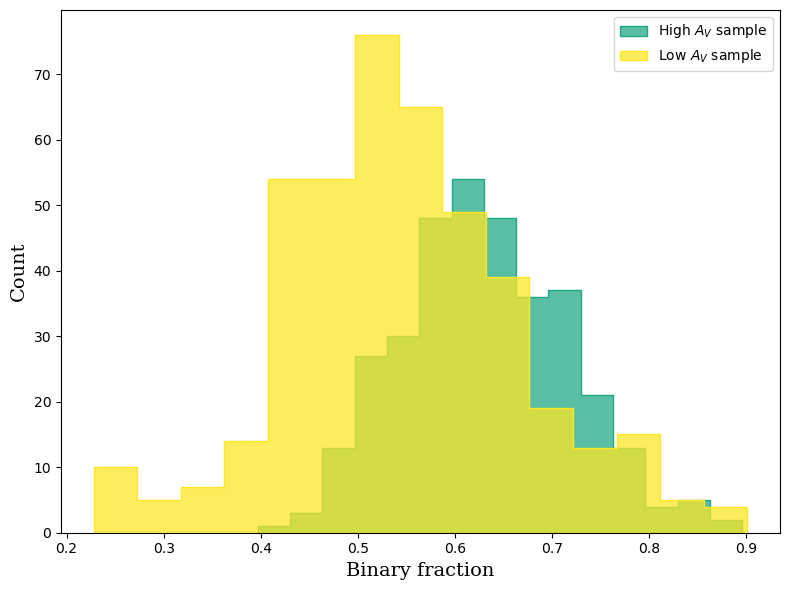

In [199]:
parametro = 'bin_frac'
label = 'Binary fraction'

fig = plt.figure(figsize=(8,6),)

ax = sns.histplot(data=df3, x=parametro, stat='count', bins=15, element='step', 
                     label=r'High $A_V$ sample',color = colors[3])
sns.histplot(data=df2, x=parametro, stat='count', bins=15, element='step', 
                     label=r'Low $A_V$ sample',color = colors[-1])

ax.set_xlabel(f'{label}', fontdict=font)
ax.set_ylabel('Count', fontdict=font)
ax.legend()

plt.tight_layout()
plt.savefig('dist_av_compracao_fb.png',bbox_inches='tight', dpi=300)
plt.show()




In [128]:
# Teste de Kolmogorov–Smirnov
for parametro in parametros:
    stat, p_value = ks_2samp(df[parametro], df2[parametro])
    print(parametro)
    print(f"Estatística KS: {stat:.4f}")
    print(f"p-valor: {p_value:.4f}")

    if p_value > 0.05:
        print("As distribuições são estatisticamente iguais.\n")
    else:
        print("As distribuições são estatisticamente diferentes.\n")

dist
Estatística KS: 0.1711
p-valor: 0.0000
As distribuições são estatisticamente diferentes.

age
Estatística KS: 0.0928
p-valor: 0.0160
As distribuições são estatisticamente diferentes.

FeH
Estatística KS: 0.0515
p-valor: 0.4383
As distribuições são estatisticamente iguais.

bin_frac
Estatística KS: 0.1682
p-valor: 0.0000
As distribuições são estatisticamente diferentes.



In [231]:
mean_baixo = np.mean(df2.bin_frac)
mean_alto = np.mean(df3.bin_frac)

# Erro padrão da média
err_baixo = np.std(df2.bin_frac, ddof=1) / np.sqrt(len(df2.bin_frac))
err_alto = np.std(df3.bin_frac, ddof=1) / np.sqrt(len(df3.bin_frac))


diff =  mean_alto- mean_baixo
err_diff = np.sqrt(err_baixo**2 + err_alto**2)

print(fr'Diferença = {diff*100:.3f}% ± {err_diff*100:.3f}%')

Diferença = 8.404% ± 0.745%


Considerando só o avermelhamento, o Teste de Kolmogorov–Smirnov indica que só a FeH continua com uma distribuição que seja estatisticamente igual ao conjunto original. Então apesar de os valores da média, mediana, maximo e minimos da fração de binárias serem basicamente identicos nos dois conjuntos, a principio com essa seleção não dá para dizer que a distribuição é a mesma.

Comparando a diferença entre a média das duas amostras, obtemos que a fração de binárias média nos aglomerados com alto Av é cerca de 8% maior que a fb média dos aglomerados de baixo Av.

In [251]:
diferencas = []
erros = []

samples = np.array_split(df.sort_values(by=['age', 'dist']), 5)

for sample in samples:
    print(f'Aglomerados com idade de log(age)={sample.age.min()} a log(age)={sample.age.max()} e distâncias entre {sample.dist.min()} kpc e {sample.dist.max()} kpc.')
    print(f'Quantidade de aglomerados com Baixo Av = {len(sample[sample.Av < 1.5])}')
    print(f'Quantidade de aglomerados com Alto Av = {len(sample[sample.Av > 1.5])}')
    
    mean_baixo = np.mean(sample[sample.Av < 1.5].bin_frac)
    mean_alto = np.mean(sample[sample.Av > 1.5].bin_frac)
    
    err_baixo = np.std(sample[sample.Av < 1.5].bin_frac, ddof=1) / np.sqrt(len(sample[sample.Av < 1.5].bin_frac))
    err_alto = np.std(sample[sample.Av > 1.5].bin_frac, ddof=1) / np.sqrt(len(sample[sample.Av > 1.5].bin_frac))
    
    diff = mean_alto - mean_baixo
    err_diff = np.sqrt(err_baixo**2 + err_alto**2)
    
    diferencas.append(diff)
    erros.append(err_diff)
    
    print('Fb média Alto Av - Fb média Baixo Av')
    print(f'Diferença = {diff*100:.3f}% ± {err_diff*100:.3f}%\n')

diferencas = np.array(diferencas)
erros = np.array(erros)

media_diff = np.mean(diferencas)
media_erro = np.sqrt(np.sum(erros**2)) / len(erros)

print(f'Média das diferenças = {media_diff*100:.3f}% ± {media_erro*100:.3f}%')


Aglomerados com idade de log(age)=6.673 a log(age)=7.559 e distâncias entre 0.175 kpc e 4.654 kpc.
Quantidade de aglomerados com Baixo Av = 53
Quantidade de aglomerados com Alto Av = 102
Fb média Alto Av - Fb média Baixo Av
Diferença = 9.827% ± 2.166%

Aglomerados com idade de log(age)=7.562 a log(age)=8.103 e distâncias entre 0.135 kpc e 4.239 kpc.
Quantidade de aglomerados com Baixo Av = 81
Quantidade de aglomerados com Alto Av = 73
Fb média Alto Av - Fb média Baixo Av
Diferença = 11.820% ± 1.621%

Aglomerados com idade de log(age)=8.104 a log(age)=8.398 e distâncias entre 0.31 kpc e 3.839 kpc.
Quantidade de aglomerados com Baixo Av = 108
Quantidade de aglomerados com Alto Av = 46
Fb média Alto Av - Fb média Baixo Av
Diferença = 7.921% ± 1.842%

Aglomerados com idade de log(age)=8.4 a log(age)=8.753 e distâncias entre 0.273 kpc e 5.205 kpc.
Quantidade de aglomerados com Baixo Av = 85
Quantidade de aglomerados com Alto Av = 69
Fb média Alto Av - Fb média Baixo Av
Diferença = 6.909% ± 

#####  Podemos ver que em todas as faixas de idade os aglomerados com Alto Av em média possuem uma fração de binárias maior, essa diferença é máxima entre 7.5< log(age) < 8.1

##### Nota-se também que para aglomerados com log(age)< 7.56, há uma predominância maior de casos de alto avermelhamento

In [250]:
diferencas = []
erros = []

samples = np.array_split(df.sort_values(by=['dist', 'age']), 5)

for sample in samples:
    print(f'Aglomerados com idade de log(age)={sample.age.min()} a log(age)={sample.age.max()} e distâncias entre {sample.dist.min()} kpc e {sample.dist.max()} kpc.')
    print(f'Quantidade de aglomerados com Baixo Av = {len(sample[sample.Av < 1.5])}')
    print(f'Quantidade de aglomerados com Alto Av = {len(sample[sample.Av > 1.5])}')
    
    mean_baixo = np.mean(sample[sample.Av < 1.5].bin_frac)
    mean_alto = np.mean(sample[sample.Av > 1.5].bin_frac)
    
    err_baixo = np.std(sample[sample.Av < 1.5].bin_frac, ddof=1) / np.sqrt(len(sample[sample.Av < 1.5].bin_frac))
    err_alto = np.std(sample[sample.Av > 1.5].bin_frac, ddof=1) / np.sqrt(len(sample[sample.Av > 1.5].bin_frac))
    
    diff = mean_alto - mean_baixo
    err_diff = np.sqrt(err_baixo**2 + err_alto**2)
    
    diferencas.append(diff)
    erros.append(err_diff)
    
    print('Fb média Alto Av - Fb média Baixo Av')
    print(f'Diferença = {diff*100:.3f}% ± {err_diff*100:.3f}%\n')

diferencas = np.array(diferencas)
erros = np.array(erros)

media_diff = np.mean(diferencas)
media_erro = np.sqrt(np.sum(erros**2)) / len(erros)

print(f'Média das diferenças = {media_diff*100:.3f}% ± {media_erro*100:.3f}%')


Aglomerados com idade de log(age)=6.744 a log(age)=9.578 e distâncias entre 0.135 kpc e 0.847 kpc.
Quantidade de aglomerados com Baixo Av = 138
Quantidade de aglomerados com Alto Av = 17
Fb média Alto Av - Fb média Baixo Av
Diferença = 12.551% ± 2.459%

Aglomerados com idade de log(age)=6.685 a log(age)=9.302 e distâncias entre 0.847 kpc e 1.333 kpc.
Quantidade de aglomerados com Baixo Av = 106
Quantidade de aglomerados com Alto Av = 48
Fb média Alto Av - Fb média Baixo Av
Diferença = 10.148% ± 1.567%

Aglomerados com idade de log(age)=6.673 a log(age)=9.525 e distâncias entre 1.335 kpc e 1.882 kpc.
Quantidade de aglomerados com Baixo Av = 73
Quantidade de aglomerados com Alto Av = 81
Fb média Alto Av - Fb média Baixo Av
Diferença = 6.685% ± 1.538%

Aglomerados com idade de log(age)=6.72 a log(age)=9.59 e distâncias entre 1.889 kpc e 2.506 kpc.
Quantidade de aglomerados com Baixo Av = 56
Quantidade de aglomerados com Alto Av = 98
Fb média Alto Av - Fb média Baixo Av
Diferença = 5.463% 

##### Quando consideramos a distância, observamos que a diferença na média de binárias para o caso de alto e baixo avermelhamento vai diminuindo em aglomerados mais distantes, mas tem que levar em consideração que há poucos aglomerados próximos e de alto Av.

##### Também podemos observar que os aglomerados de Alto Av só passam a ser predominantes em dist > 1.3 kpc

# Correlação dos Dados

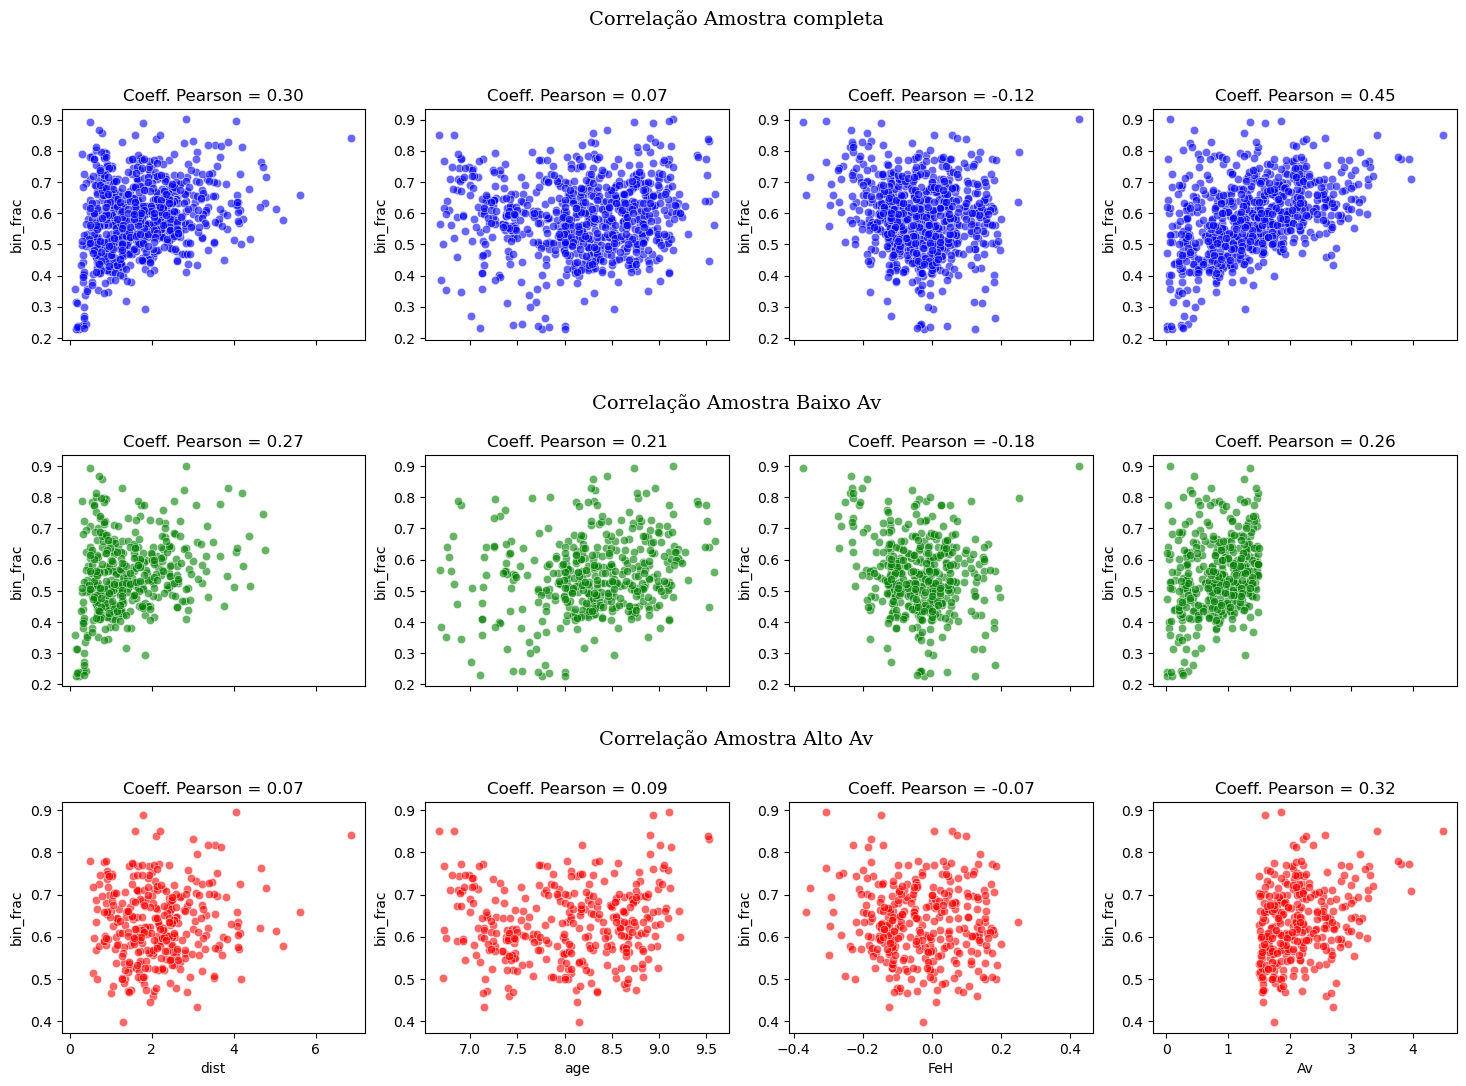

In [129]:


# Pares de variáveis a comparar
parametros_plot = [
    ('dist', 'bin_frac'),
    ('age', 'bin_frac'),
    ('FeH', 'bin_frac'),
    ('Av','bin_frac')
]


n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12),gridspec_kw={'hspace': 0.5}, sharex='col')

# Adiciona títulos para as duas linhas
fig.text(0.5, 0.95, 'Correlação Amostra completa', ha='center', fontdict=font)
fig.text(0.5, 0.63, 'Correlação Amostra Baixo Av', ha='center', fontdict=font, )
fig.text(0.5, 0.35, 'Correlação Amostra Alto Av', ha='center', fontdict=font, )

for idx, (x_param, y_param) in enumerate(parametros_plot):
    # Primeira linha: df
    ax1 = axes[0, idx]
    sns.scatterplot(data=df, x=x_param, y=y_param, ax=ax1, color='b', alpha=0.6)
    corr1, _ = pearsonr(df[x_param], df[y_param])
    ax1.set_title(f'\nCoeff. Pearson = {corr1:.2f}')
    ax1.set_xlabel(x_param)
    ax1.set_ylabel(y_param)

    # Segunda linha: df2
    ax2 = axes[1, idx]
    sns.scatterplot(data=df2, x=x_param, y=y_param, ax=ax2, color='g', alpha=0.6)
    corr2, _ = pearsonr(df2[x_param], df2[y_param])
    ax2.set_title(f'\nCoeff. Pearson = {corr2:.2f}')
    ax2.set_xlabel(x_param)
    ax2.set_ylabel(y_param)
    
    # Terceira linha: df3
    ax3 = axes[2, idx]
    sns.scatterplot(data=df3, x=x_param, y=y_param, ax=ax3, color='r', alpha=0.6)
    corr3, _ = pearsonr(df3[x_param], df3[y_param])
    ax3.set_title(f'\nCoeff. Pearson = {corr3:.2f}')
    ax3.set_xlabel(x_param)
    ax3.set_ylabel(y_param)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Em relação a correlação da fb com os parametros dos aglomerados a principal mudança é em relação a idade, que para o caso de baixo Av a correlação é um tanto maior que no caso geral. Na metalicidade a correlação fica pouco mais significativa. Com a distância dá uma leve diminuida e, como esperado, na metalicidade diminui bastante 

# Fração de binárias por faixa de massa

In [118]:
def fracao_binarias_por_faixa_de_massa(df):
    """
    Calcula a fração de sistemas binários em função da massa da estrela primária.

    Considera apenas faixas com pelo menos 20 estrelas membros

    Faixas:
        - VLM (Very Low Mass): M < 0.7
        - ST (Solar Type): 0.7 <= M < 1.5
        - IM (Intermediate Mass): 1.5 <= M < 5
        - HM (High Mass): M >= 5
    """
    # Classificação da massa
    def classificar_massa(m):
        if m < 0.7:
            return 'VLM'
        elif m < 1.5:
            return 'ST'
        elif m < 5:
            return 'IM'
        else:
            return 'HM'

    df = df.copy()
    df['mass_class'] = df['mass'].apply(classificar_massa)

    categorias = ['VLM', 'ST', 'IM', 'HM']

    def calcular_fracao(g):
        if len(g) >= 10:
            return (g['comp_mass'] > 0).sum() / len(g)
        else:
            return float('nan')

    frac_bin = df.groupby('mass_class').apply(calcular_fracao)

    frac_bin = frac_bin.reindex(categorias)

    return frac_bin



In [119]:
fracao_binarias_por_faixa_de_massa(data)

mass_class
VLM    0.418090
ST     0.554174
IM     0.680822
HM     0.641561
dtype: float64

In [120]:
fracao_binarias_por_faixa_de_massa(data[data.Av<1.5])

mass_class
VLM    0.403631
ST     0.513918
IM     0.718129
HM     0.715517
dtype: float64

In [121]:
fracao_binarias_por_faixa_de_massa(data[data.Av>1.5])

mass_class
VLM    0.637155
ST     0.611145
IM     0.651850
HM     0.606941
dtype: float64

Considerando apenas os aglomerados com baixo Av, a fração de binárias em estrelas de alta massa e massa intermediária são maiores que no caso da amostra completa, principalmente nos sistemas de alta massa.
Para estrelas do tipo solar e de baixa massa, teve uma diminuição na fração de binárias na amostra com baixo Av.

Olhando para a sub-amostra dos aglomerados com Alto Av, podemos ver que há uma maior frquência de sistemas binários em estrelas do tipo solar e de baixa massa, isso talvez indique que o avermelhamento está afetando principalmente a determinação de binárias em sistemas com massa $M<1.5$, visto que a diferença é da fração de binárias desses grupos é consideravel em comparação as outras amostras.

In [122]:
colunas = ['bin_frac_vlm','bin_frac_st','bin_frac_im','bin_frac_hm']
df[colunas] = np.nan
mass_class =['VLM', 'ST', 'IM', 'HM']
for aglomerado in df.index:
    aux = fracao_binarias_por_faixa_de_massa(data.loc[aglomerado])
    for i in range(0,len(colunas)):
        df[colunas[i]].loc[aglomerado]= aux.loc[mass_class[i]]     
df2 = df[df.Av<1.5]
df3 = df[df.Av>1.5]

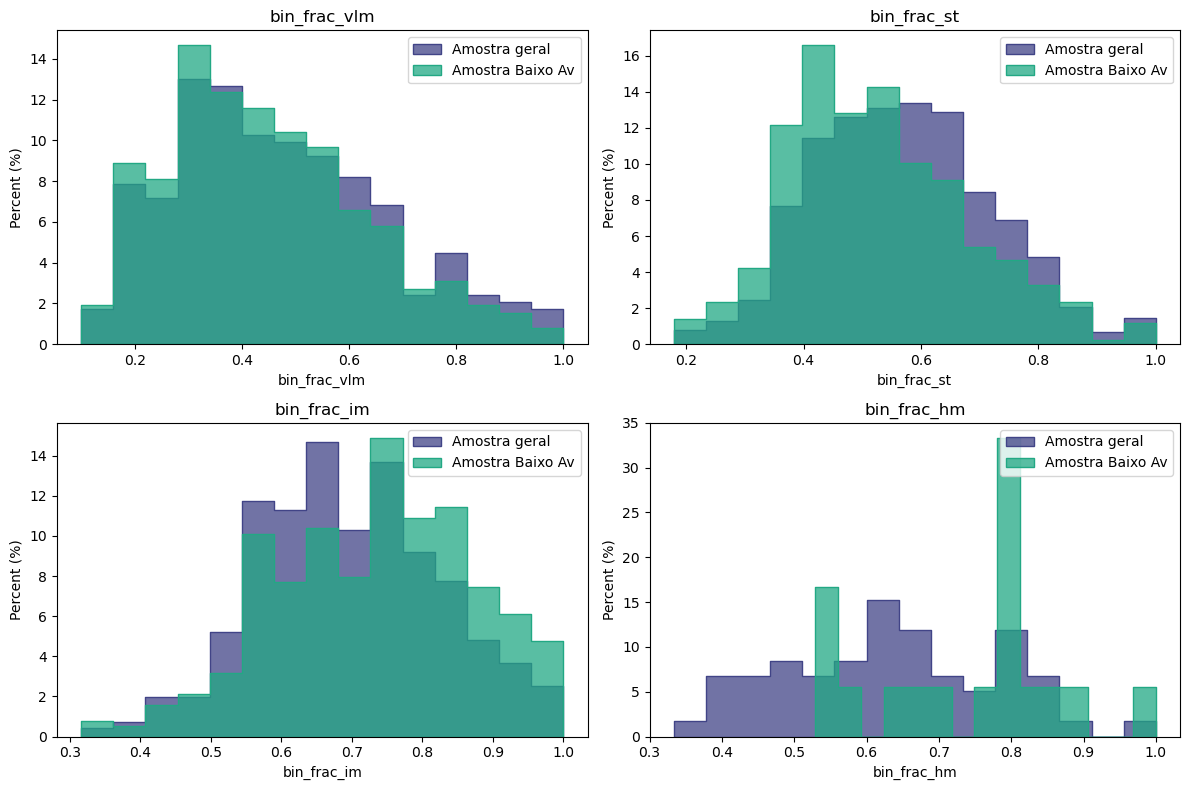

In [183]:
n_rows = 2
n_cols = 2
plots_por_figura = n_rows * n_cols

for i in range(0, len(colunas), plots_por_figura):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
    axes = axes.flatten()

    for j in range(plots_por_figura):
        if i + j >= len(colunas):
            break

        ax = axes[j]
        parametro = colunas[i + j]

        sns.histplot(data=df, x=parametro, stat='percent', bins=15, element='step', ax=ax, 
                     label='Amostra geral', color=colors[1])
        sns.histplot(data=df2, x=parametro, stat='percent', bins=15, element='step', ax=ax, 
                     label='Amostra Baixo Av',color=colors[-3])


        ax.set_title(f'{parametro}')
        ax.set_ylabel('Percent (%)')
        ax.legend()

    for k in range(j + 1, plots_por_figura):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()



In [124]:
# Teste de Kolmogorov–Smirnov
for coluna in colunas:
    stat, p_value = ks_2samp(df[coluna], df2[coluna])
    print(coluna)
    print(f"Estatística KS: {stat:.4f}")
    print(f"p-valor: {p_value:.4f}")

    if p_value > 0.05:
        print("As distribuições são estatisticamente iguais.\n")
    else:
        print("As distribuições são estatisticamente diferentes.\n")

bin_frac_vlm
Estatística KS: 0.2273
p-valor: 0.0000
As distribuições são estatisticamente diferentes.

bin_frac_st
Estatística KS: 0.1480
p-valor: 0.0000
As distribuições são estatisticamente diferentes.

bin_frac_im
Estatística KS: 0.1488
p-valor: 0.0000
As distribuições são estatisticamente diferentes.

bin_frac_hm
Estatística KS: 0.0420
p-valor: 0.6937
As distribuições são estatisticamente iguais.



In [125]:
for parametro in parametros:
    colunas.append(parametro)

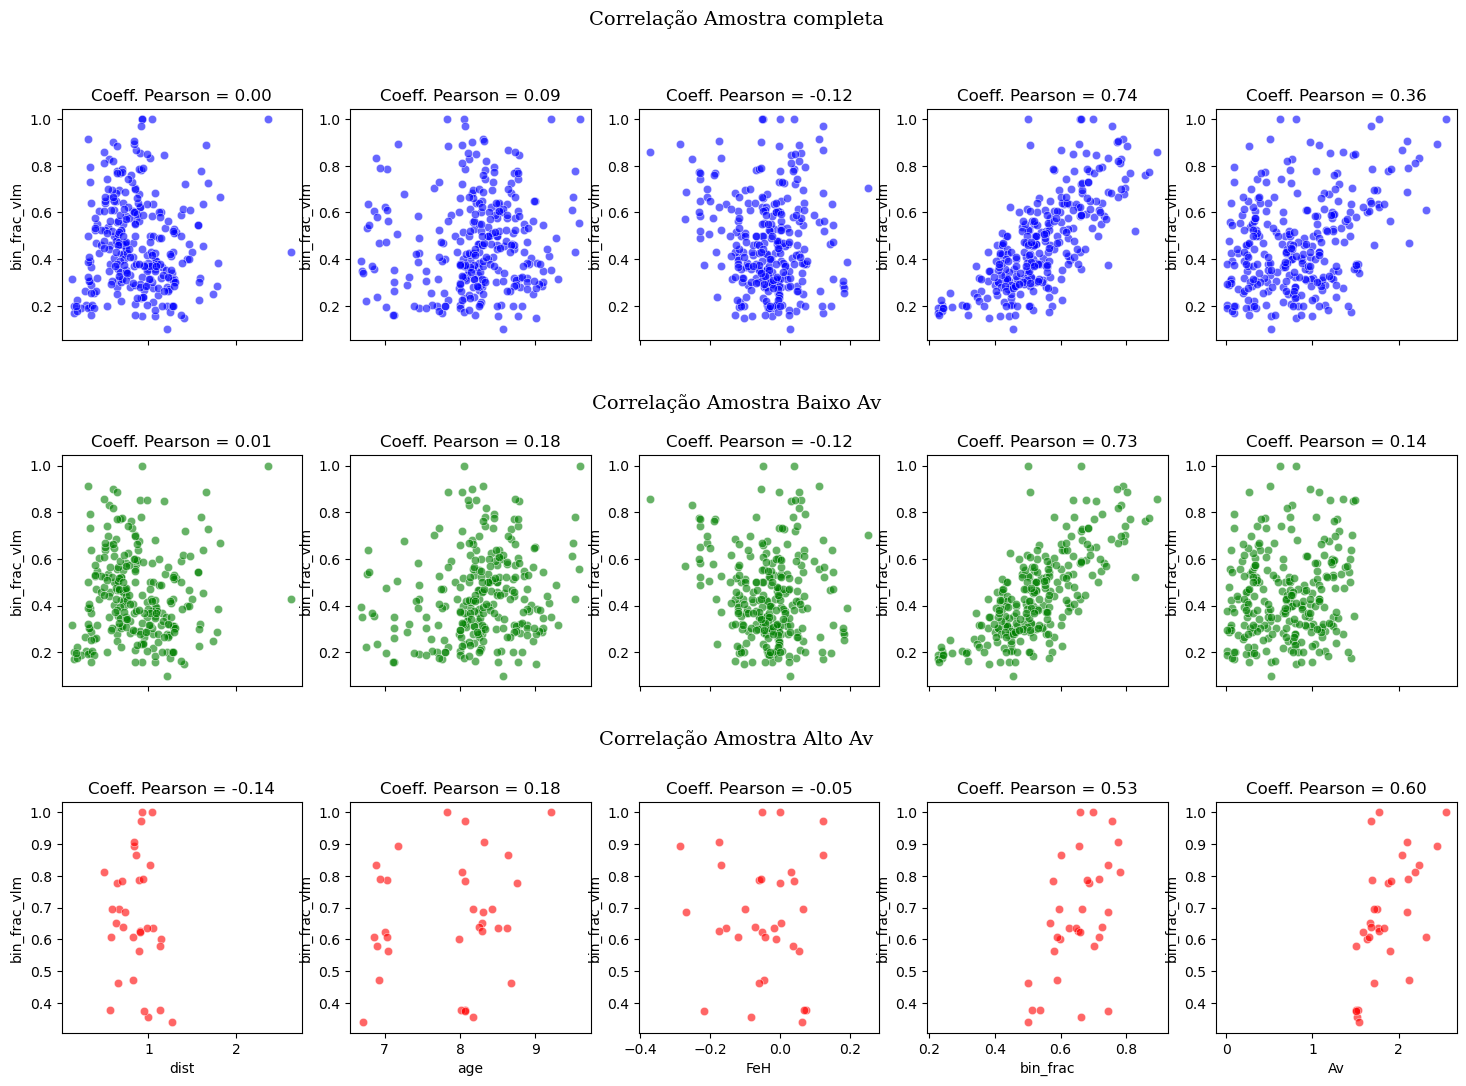

In [126]:
# Fb em estrelas de baixa massa

# Pares de variáveis a comparar
parametros_plot = [
    ('dist', 'bin_frac_vlm'),
    ('age', 'bin_frac_vlm'),
    ('FeH', 'bin_frac_vlm'),
    ('bin_frac', 'bin_frac_vlm'),
    ('Av','bin_frac_vlm')
]


n_rows = 3
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12),gridspec_kw={'hspace': 0.5}, sharex='col')

# Adiciona títulos para as duas linhas
fig.text(0.5, 0.95, 'Correlação Amostra completa', ha='center', fontdict=font)
fig.text(0.5, 0.63, 'Correlação Amostra Baixo Av', ha='center', fontdict=font, )
fig.text(0.5, 0.35, 'Correlação Amostra Alto Av', ha='center', fontdict=font, )

for idx, (x_param, y_param) in enumerate(parametros_plot):
    # Primeira linha: df
    ax1 = axes[0, idx]
    sns.scatterplot(data=df, x=x_param, y=y_param, ax=ax1, color='b', alpha=0.6)
    corr1, _ = pearsonr(df[[y_param, x_param]].dropna()[x_param], df[y_param].dropna())
    ax1.set_title(f'\nCoeff. Pearson = {corr1:.2f}')
    ax1.set_xlabel(x_param)
    ax1.set_ylabel(y_param)

    # Segunda linha: df2
    ax2 = axes[1, idx]
    sns.scatterplot(data=df2, x=x_param, y=y_param, ax=ax2, color='g', alpha=0.6)
    corr2, _ = pearsonr(df2[[y_param, x_param]].dropna()[x_param], df2[y_param].dropna())
    ax2.set_title(f'\nCoeff. Pearson = {corr2:.2f}')
    ax2.set_xlabel(x_param)
    ax2.set_ylabel(y_param)
    
    # Terceira linha: df3
    ax3 = axes[2, idx]
    sns.scatterplot(data=df3, x=x_param, y=y_param, ax=ax3, color='r', alpha=0.6)
    corr3, _ = pearsonr(df3[[y_param, x_param]].dropna()[x_param], df3[y_param].dropna())
    ax3.set_title(f'\nCoeff. Pearson = {corr3:.2f}')
    ax3.set_xlabel(x_param)
    ax3.set_ylabel(y_param)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


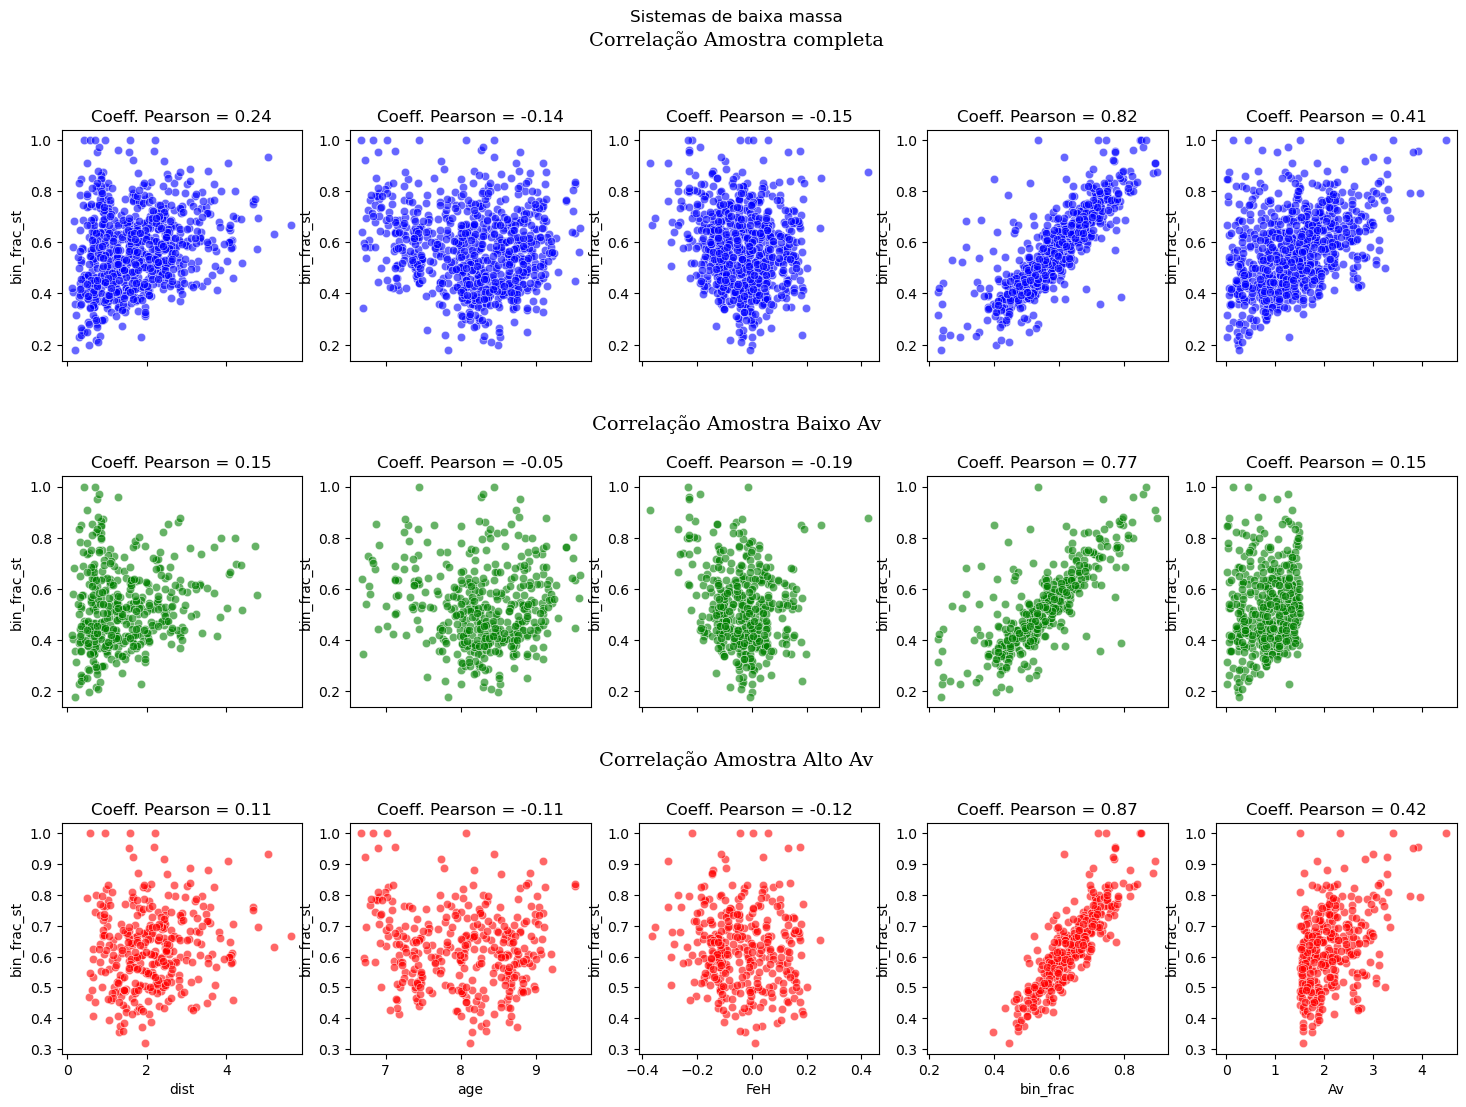

In [127]:
# Fb em estrelas do tipo solar

# Pares de variáveis a comparar
parametros_plot = [
    ('dist', 'bin_frac_st'),
    ('age', 'bin_frac_st'),
    ('FeH', 'bin_frac_st'),
    ('bin_frac', 'bin_frac_st'),
    ('Av','bin_frac_st')
]


n_rows = 3
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12),gridspec_kw={'hspace': 0.5}, sharex='col')
fig.suptitle('Sistemas de baixa massa')
# Adiciona títulos para as duas linhas
fig.text(0.5, 0.95, 'Correlação Amostra completa', ha='center', fontdict=font)
fig.text(0.5, 0.63, 'Correlação Amostra Baixo Av', ha='center', fontdict=font, )
fig.text(0.5, 0.35, 'Correlação Amostra Alto Av', ha='center', fontdict=font, )

for idx, (x_param, y_param) in enumerate(parametros_plot):
    # Primeira linha: df
    ax1 = axes[0, idx]
    sns.scatterplot(data=df, x=x_param, y=y_param, ax=ax1, color='b', alpha=0.6)
    corr1, _ = pearsonr(df[[y_param, x_param]].dropna()[x_param], df[y_param].dropna())
    ax1.set_title(f'\nCoeff. Pearson = {corr1:.2f}')
    ax1.set_xlabel(x_param)
    ax1.set_ylabel(y_param)

    # Segunda linha: df2
    ax2 = axes[1, idx]
    sns.scatterplot(data=df2, x=x_param, y=y_param, ax=ax2, color='g', alpha=0.6)
    corr2, _ = pearsonr(df2[[y_param, x_param]].dropna()[x_param], df2[y_param].dropna())
    ax2.set_title(f'\nCoeff. Pearson = {corr2:.2f}')
    ax2.set_xlabel(x_param)
    ax2.set_ylabel(y_param)
    
    # Terceira linha: df3
    ax3 = axes[2, idx]
    sns.scatterplot(data=df3, x=x_param, y=y_param, ax=ax3, color='r', alpha=0.6)
    corr3, _ = pearsonr(df3[[y_param, x_param]].dropna()[x_param], df3[y_param].dropna())
    ax3.set_title(f'\nCoeff. Pearson = {corr3:.2f}')
    ax3.set_xlabel(x_param)
    ax3.set_ylabel(y_param)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


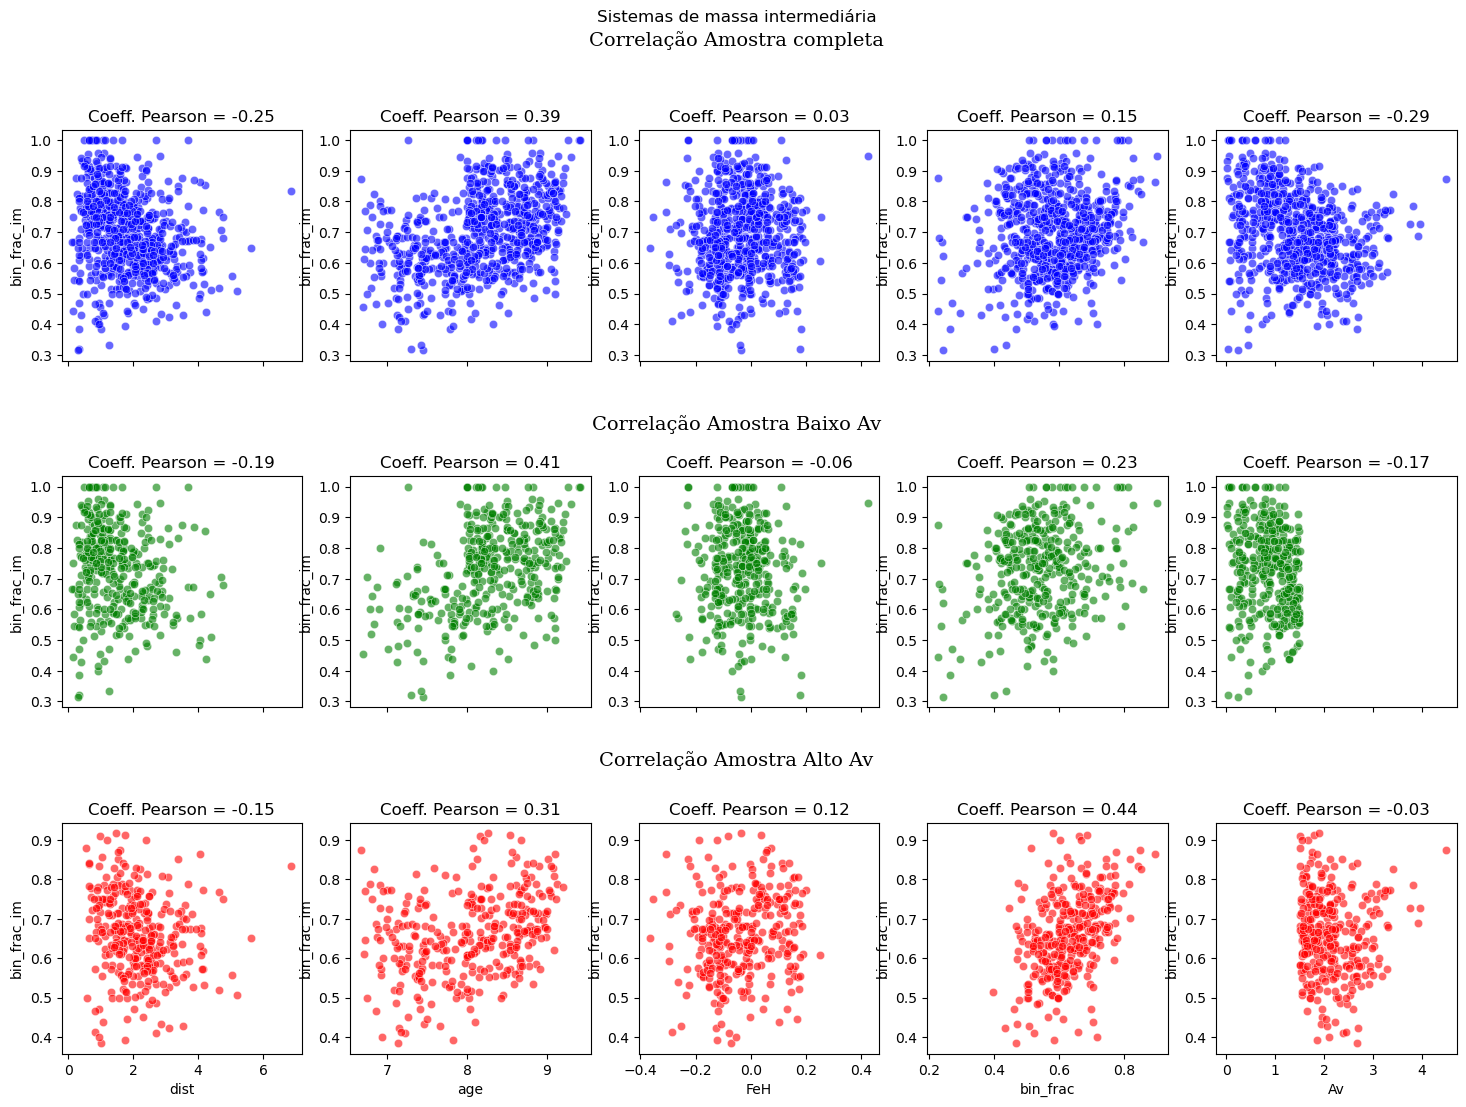

In [128]:
# Fb em estrelas de massa intermediaria

# Pares de variáveis a comparar
parametros_plot = [
    ('dist', 'bin_frac_im'),
    ('age', 'bin_frac_im'),
    ('FeH', 'bin_frac_im'),
    ('bin_frac', 'bin_frac_im'),
    ('Av','bin_frac_im')
]


n_rows = 3
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12),gridspec_kw={'hspace': 0.5}, sharex='col')
fig.suptitle('Sistemas de massa intermediária')
# Adiciona títulos para as duas linhas
fig.text(0.5, 0.95, 'Correlação Amostra completa', ha='center', fontdict=font)
fig.text(0.5, 0.63, 'Correlação Amostra Baixo Av', ha='center', fontdict=font, )
fig.text(0.5, 0.35, 'Correlação Amostra Alto Av', ha='center', fontdict=font, )

for idx, (x_param, y_param) in enumerate(parametros_plot):
    # Primeira linha: df
    ax1 = axes[0, idx]
    sns.scatterplot(data=df, x=x_param, y=y_param, ax=ax1, color='b', alpha=0.6)
    corr1, _ = pearsonr(df[[y_param, x_param]].dropna()[x_param], df[y_param].dropna())
    ax1.set_title(f'\nCoeff. Pearson = {corr1:.2f}')
    ax1.set_xlabel(x_param)
    ax1.set_ylabel(y_param)

    # Segunda linha: df2
    ax2 = axes[1, idx]
    sns.scatterplot(data=df2, x=x_param, y=y_param, ax=ax2, color='g', alpha=0.6)
    corr2, _ = pearsonr(df2[[y_param, x_param]].dropna()[x_param], df2[y_param].dropna())
    ax2.set_title(f'\nCoeff. Pearson = {corr2:.2f}')
    ax2.set_xlabel(x_param)
    ax2.set_ylabel(y_param)
    
    # Terceira linha: df3
    ax3 = axes[2, idx]
    sns.scatterplot(data=df3, x=x_param, y=y_param, ax=ax3, color='r', alpha=0.6)
    corr3, _ = pearsonr(df3[[y_param, x_param]].dropna()[x_param], df3[y_param].dropna())
    ax3.set_title(f'\nCoeff. Pearson = {corr3:.2f}')
    ax3.set_xlabel(x_param)
    ax3.set_ylabel(y_param)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


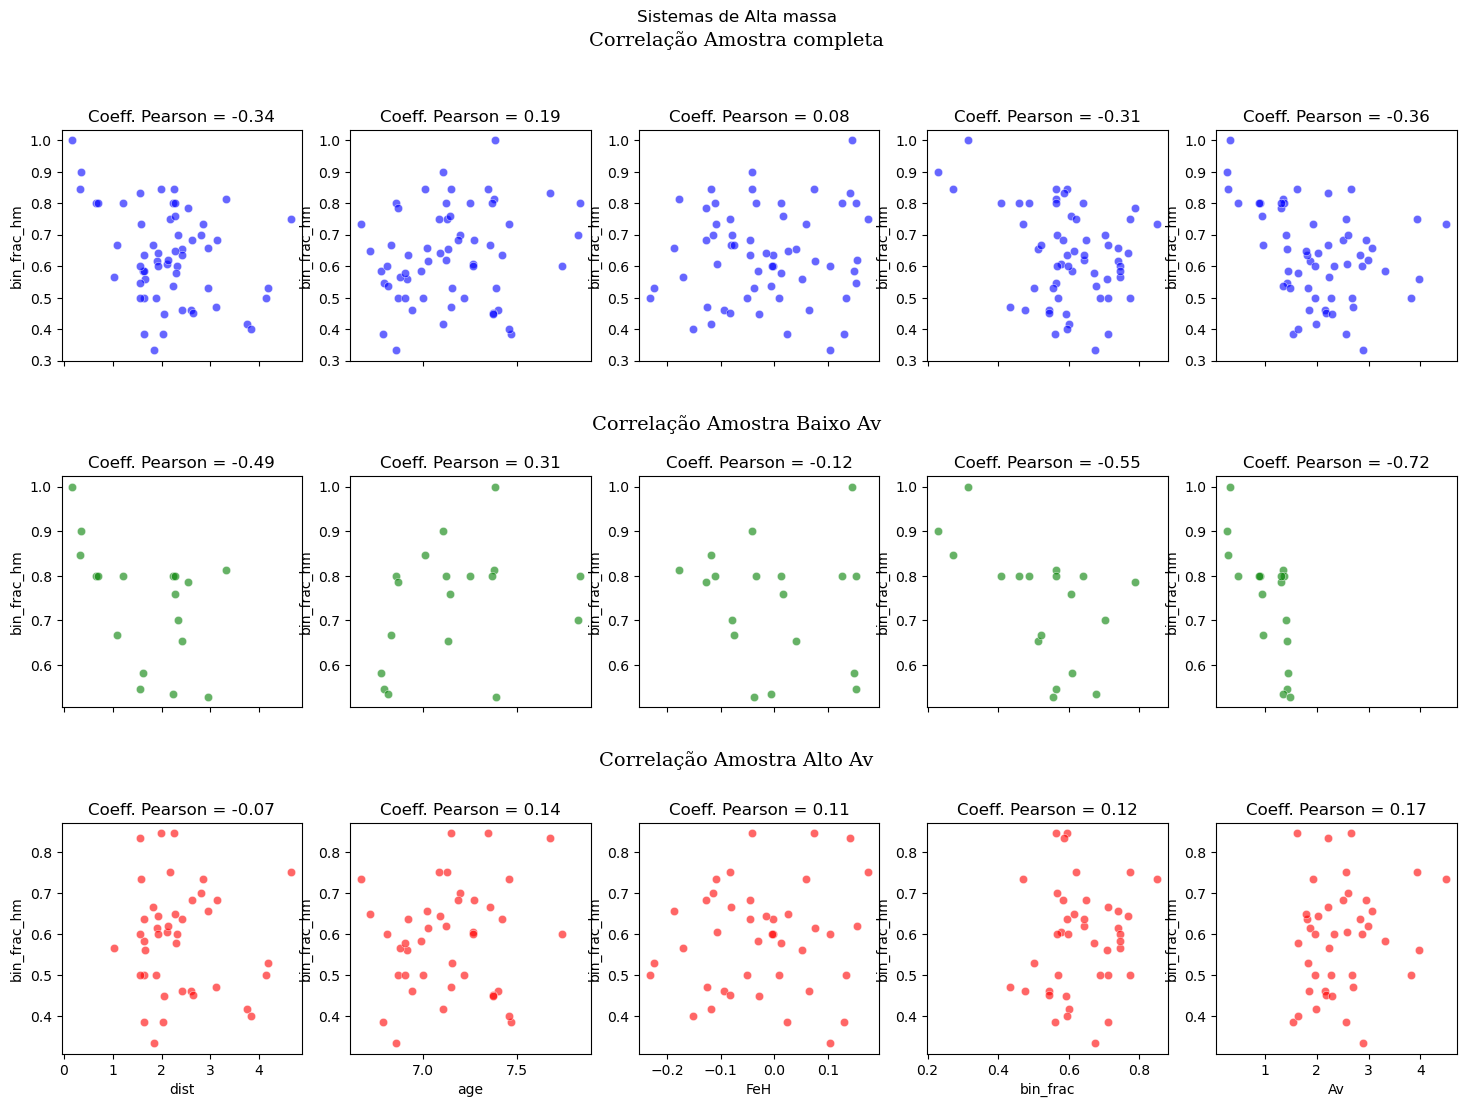

In [129]:
# Fb em estrelas de alta massa

# Pares de variáveis a comparar
parametros_plot = [
    ('dist', 'bin_frac_hm'),
    ('age', 'bin_frac_hm'),
    ('FeH', 'bin_frac_hm'),
    ('bin_frac', 'bin_frac_hm'),
    ('Av','bin_frac_hm')
]


n_rows = 3

n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12),gridspec_kw={'hspace': 0.5}, sharex='col')
fig.suptitle('Sistemas de Alta massa')
# Adiciona títulos para as duas linhas
fig.text(0.5, 0.95, 'Correlação Amostra completa', ha='center', fontdict=font)
fig.text(0.5, 0.63, 'Correlação Amostra Baixo Av', ha='center', fontdict=font, )
fig.text(0.5, 0.35, 'Correlação Amostra Alto Av', ha='center', fontdict=font, )

for idx, (x_param, y_param) in enumerate(parametros_plot):
    # Primeira linha: df
    ax1 = axes[0, idx]
    sns.scatterplot(data=df, x=x_param, y=y_param, ax=ax1, color='b', alpha=0.6)
    corr1, _ = pearsonr(df[[y_param, x_param]].dropna()[x_param], df[y_param].dropna())
    ax1.set_title(f'\nCoeff. Pearson = {corr1:.2f}')
    ax1.set_xlabel(x_param)
    ax1.set_ylabel(y_param)

    # Segunda linha: df2
    ax2 = axes[1, idx]
    sns.scatterplot(data=df2, x=x_param, y=y_param, ax=ax2, color='g', alpha=0.6)
    corr2, _ = pearsonr(df2[[y_param, x_param]].dropna()[x_param], df2[y_param].dropna())
    ax2.set_title(f'\nCoeff. Pearson = {corr2:.2f}')
    ax2.set_xlabel(x_param)
    ax2.set_ylabel(y_param)
    
    # Terceira linha: df3
    ax3 = axes[2, idx]
    sns.scatterplot(data=df3, x=x_param, y=y_param, ax=ax3, color='r', alpha=0.6)
    corr3, _ = pearsonr(df3[[y_param, x_param]].dropna()[x_param], df3[y_param].dropna())
    ax3.set_title(f'\nCoeff. Pearson = {corr3:.2f}')
    ax3.set_xlabel(x_param)
    ax3.set_ylabel(y_param)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


Os gráficos de correlação confirmam a tendência do aumento de binárias de baixa massa e do tipo solar com o avermelhamento dos aglomerados, essa influência se inverte em sistemas mais massivos

# Conclusão

1. Em média, os aglomerados com alto Av, posssuem uma fb cerca de 8% maior em relação a aglomerados de baixo Av

2. Aglomerados de alto avermelhamento são predominantes em aglomerados com log(age)< 7.5

3. Em relação a distância, a diferença entre as médias da fb dos aglomerados de baixo e alto av parecem diminuir em aglomerados mais distantes.

4. O avermelhamento parece afetar principalmente estrelas com M<1.5, a fração de binárias em sistemas nessa faixa de massa tem uma correlação bastante significativa com o avermelhamento, para sistemas mais massivos essa correlação se torna negativa.

O fato do avermelhamento influenciar mais significativamente a fb em estrelas menos massivas, pode justificar o fato de que em aglomerados distantes a diferença da média da fb nos casos de alto e baixo Av diminui. Assim como tabmbém em aglomerados mais velhos há um aumento nessa diferença, pois eles são predominantementes formados por estrelas de baixa massa.

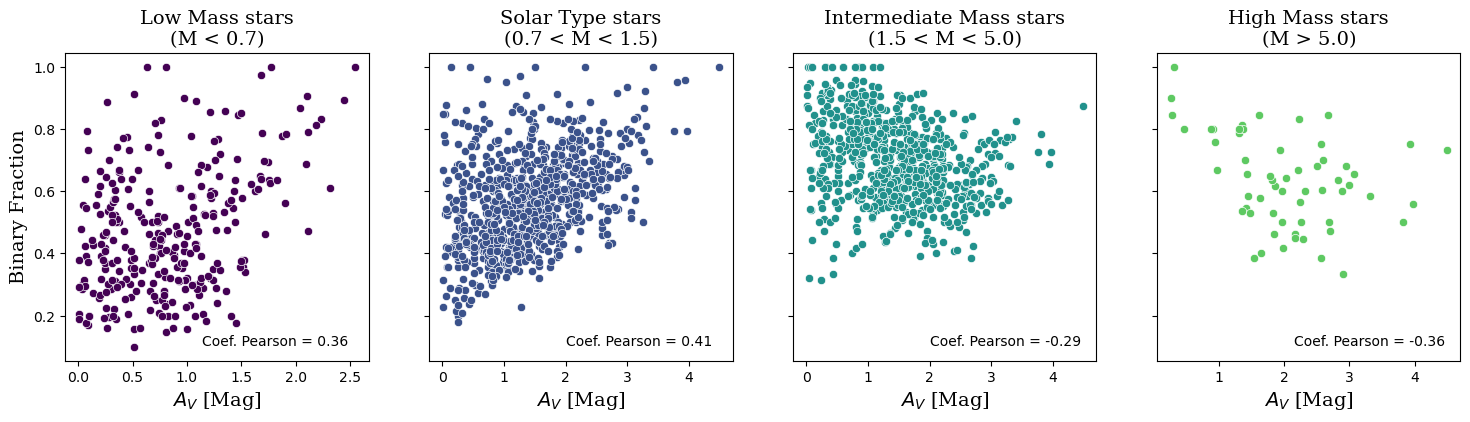

In [203]:
import matplotlib.cm as cm
from scipy.stats import pearsonr

# Cores ajustadas da paleta 'viridis'
viridis = cm.get_cmap('viridis', 9)  # 4 cores diferentes
colors = [viridis(i) for i in range(8)]

# Nomes dos subplots
titles = [
    'Low Mass stars\n(M < 0.7)', 
    'Solar Type stars\n(0.7 < M < 1.5)', 
    'Intermediate Mass stars\n(1.5 < M < 5.0)', 
    'High Mass stars\n(M > 5.0)'
]
colunas = ['bin_frac_vlm', 'bin_frac_st', 'bin_frac_im', 'bin_frac_hm']

# Criação dos subplots
fig, axes = plt.subplots(1, 4, figsize=(18, 4), gridspec_kw={'hspace': 0.5}, sharex='col',
                        sharey=True)

for i in range(4):
    x = df['Av']
    y = df[colunas[i]]

    # Cálculo do coeficiente de Pearson
    mask = ~np.isnan(x) & ~np.isnan(y)  # Garante que não tem NaN no cálculo
    r, _ = pearsonr(x[mask], y[mask])

    # Scatter plot
    sns.scatterplot(
        data=df, 
        x='Av', 
        y=colunas[i], 
        ax=axes[i], 
        color=colors[i*2]
    )

    # Título e labels
    axes[i].set_title(titles[i], fontdict = font)
    axes[i].set_xlabel(r'$A_V$ [Mag]', fontdict = font)
    axes[i].set_ylabel('Binary Fraction', fontdict = font)

    # Adicionar o coeficiente no gráfico
    axes[i].text(0.45, 0.05, f'Coef. Pearson = {r:.2f}', transform=axes[i].transAxes,
                 fontsize=10, bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.tight_layout()
plt.show()

In [9]:
df[(df['RA_ICRS']>=225) & (df['RA_ICRS']<=285) & (df['DE_ICRS']<=20) & (df['DE_ICRS']>=-20)].sort_values(by='RA_ICRS')

,RA_ICRS,DE_ICRS,dist,e_dist,age,e_age,FeH,e_FeH,Av,e_Av,...,offset_er_int,mass_total,e_mass_total,bin_frac,average_ratio,str_average_ratio,segr_ratio,segr_ratio_std,mass_seg,mass_seg_pval
Cluster,,,,,,,,,,,,,,,,,,,,,
IC_4665,266.6712,5.5021,0.310,0.013,8.309,0.270,0.112,0.066,0.510,0.148,...,0.17094,308,61,0.788845,0.82766,0.19099,1.21903,2.87789,0.18955,0.16330
Gulliver_20,273.7950,10.9935,0.415,0.008,8.853,0.085,-0.025,0.036,0.297,0.041,...,0.09594,136,27,0.519608,0.61088,0.22407,1.17154,3.91181,0.18296,0.60404
Markarian_38,273.8232,-19.0070,1.662,0.048,7.164,0.161,0.031,0.071,1.061,0.048,...,0.13570,156,31,0.638889,0.56932,0.26650,0.96027,1.22598,0.27143,0.54388
Trumpler_32,274.2983,-13.3320,1.605,0.031,8.874,0.036,0.079,0.033,2.431,0.020,...,0.08871,1422,284,0.617699,0.74902,0.25730,1.13232,2.20989,0.16045,0.01189
Dias_5,274.3605,-19.6916,1.264,0.018,6.715,0.153,0.064,0.056,1.537,0.528,...,0.04816,517,103,0.501832,0.74047,0.22451,0.91084,1.47131,0.08886,0.65496
NGC_6604,274.5254,-12.2434,1.935,0.037,6.809,0.057,0.103,0.077,2.881,0.037,...,0.06115,871,174,0.746377,0.76381,0.20726,NaN,NaN,0.26905,0.33846
Trumpler_33,276.1694,-19.7200,1.333,0.024,7.836,0.154,0.061,0.096,1.488,0.081,...,0.10056,313,62,0.584906,0.57382,0.27799,1.07978,1.16156,0.17785,0.33598
UBC_347,276.7298,-10.9679,1.267,0.034,8.727,0.203,0.069,0.078,3.004,0.075,...,0.26902,232,46,0.680556,0.68214,0.24592,1.42542,1.14163,0.38889,0.02834
NGC_6633,276.8650,6.6414,0.391,0.002,8.901,0.175,-0.117,0.043,0.549,0.238,...,0.11982,512,102,0.695971,0.67544,0.22046,1.10947,2.23366,0.14728,0.10059


In [8]:
data.loc['Dias_5']

17.063145080586082